In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt

import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [5]:
index_min = 0
index_max = 200

E = data['E'][index_min:index_max]
Q_GT = data['q'][index_min:index_max]
T_GT = data['t'][index_min:index_max]
volume = data['n']  # The refractive index volume

In [6]:
E_upd = E.copy()

In [7]:
def correctfield(field, n_iter=5):
    """
    Correct field
    """

    if field.dtype == torch.float32:
        field = field.to(torch.complex64)

    f_new = field.clone()

    # Normalize with mean of absolute value.
    f_new = f_new / torch.mean(torch.abs(f_new))

    for _ in range(n_iter):
        f_new = f_new * torch.exp(-1j * torch.median(torch.angle(f_new)))

    return f_new

In [8]:
#E = correctfield(torch.tensor(E_upd, device=DEV, dtype=torch.complex64), n_iter=5).cpu().numpy()

In [9]:
#E = E * np.exp(-1j * np.angle(E[:, :20, :20]).mean(axis=(1,2), keepdims=True))

In [10]:
# Make 2 channels for imag and real part
#E = np.stack([np.real(E), np.imag(E)], axis=1)

In [11]:
#E.shape

In [12]:
#E.shape

In [13]:
#projections = torch.tensor(E, dtype=torch.float32).to(DEV)

In [14]:
nx, ny, nz = 174, 200, 150

In [15]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# Setup the optics
optics_settings = setup_optics(
        shape=(nx, ny, nz),
        padding_xy=0, 
        microscopy_regime='Brightfield', 
        NA=1.15, 
        wavelength=640e-9, 
        resolution=200e-9, 
        magnification=1, 
        return_field=True)

# Generate the imaging model
brightfield_model = imaging_model(optics_setup=optics_settings)

In [16]:
from skimage.restoration import unwrap_phase
from scipy.signal import find_peaks

PU = [unwrap_phase(np.angle(E)) for E in E]

def calc_cc(a, b):
    return np.abs(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b))).max()

cc = []
for i in range(0, 200):
    cc.append(calc_cc(PU[0], PU[i]))
cc = np.array(cc)

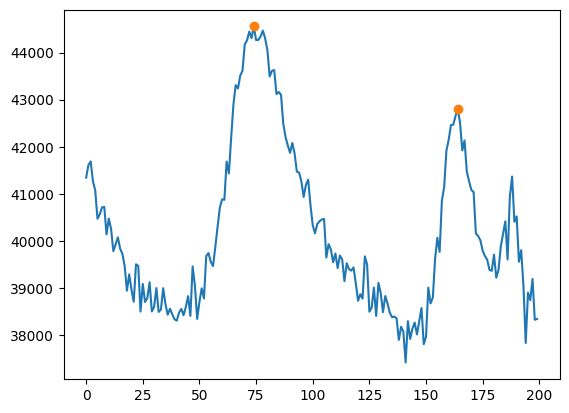

In [17]:
pks = find_peaks(cc, width=10)[0]

plt.plot(cc)
plt.plot(pks, cc[pks], 'o')

In [18]:
th = np.array([0.])
for i, pk in enumerate(pks):
    th = np.r_[th, np.linspace(i*np.pi, (i+1)*np.pi, (pks[i] - pks[i-1]) + 1 if i>0 else pks[i])[1:]]
th = np.r_[th, np.linspace((i+1)*np.pi, (i+1)*np.pi + np.pi * ((200 - pks[i]) / (pks[i] - pks[i-1])) , 200 - pks[i] + 1)[1:]]

In [19]:
Q_GT_new = np.zeros_like(Q_GT)
Q_GT_new[:, 0] = Q_GT[:, 0]
Q_GT_new[:, 1] = -Q_GT[:, 2]
Q_GT_new[:, 2] = -Q_GT[:, 3]
Q_GT_new[:, 3] = -Q_GT[:, 1]

dx = 200e-9
T_GT_new = np.zeros_like(T_GT)
T_GT_new[:, 0] = T_GT[:, 1] / dx
T_GT_new[:, 1] = T_GT[:, 2] / dx
T_GT_new[:, 2] = (T_GT[:, 0] - 150 * dx / 2) / dx


In [ ]:
Q_start = np.zeros_like(Q_GT_new)
Q_start[:, 0] = np.cos(-th/2)
Q_start[:, 2] = np.sin(-th/2)

T_start = np.zeros_like(T_GT_new)
T_start[:, 2] = - 40.

In [21]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=(nx, ny, nz), # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model,
    automatic_optimization=False, # Manual optimization
    )

In [22]:
E = E * np.exp(-1j * np.angle(E[:, :20, :20]).mean(axis=(1,2), keepdims=True))

# Make 2 channels for imag and real part
E = np.stack([np.real(E), np.imag(E)], axis=1)

# create projections tensor
projections = torch.tensor(E, dtype=torch.float32).to(DEV)

In [23]:
# Initialize the parameters
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=125)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name                | Type                 | Params | Mode 
---------------------------------------------------------------------
0 | encoder             | Sequential           | 80.1 K | train
1 | fc_mu               | MultiLayerPerceptron | 281 K 

Epoch 124: 100%|██████████| 7/7 [00:00<00:00, 16.25it/s, v_num=1381, train_rec_loss_step=0.120, train_KL_step=47.60, train_total_loss_step=0.121, train_rec_loss_epoch=0.119, train_KL_epoch=163.0, train_total_loss_epoch=0.120]  


For vizualisation we initialize a `TomoPlotter` class.

In [24]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)


Using the VAE, we can visualize the **latent space** over time, revealing a trajectory that captures the system’s dynamics. Notably, **rotational movements** appear as transitions in this space, showing how the model encodes changes in orientation.


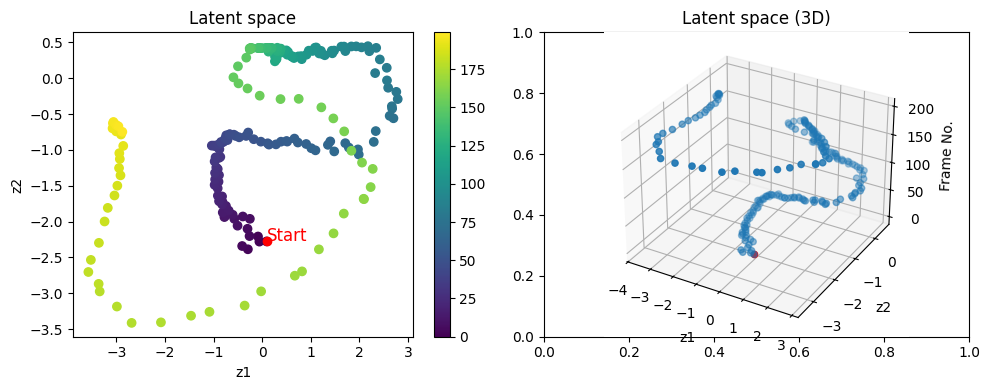

In [25]:
plotter.plot_latent_space()

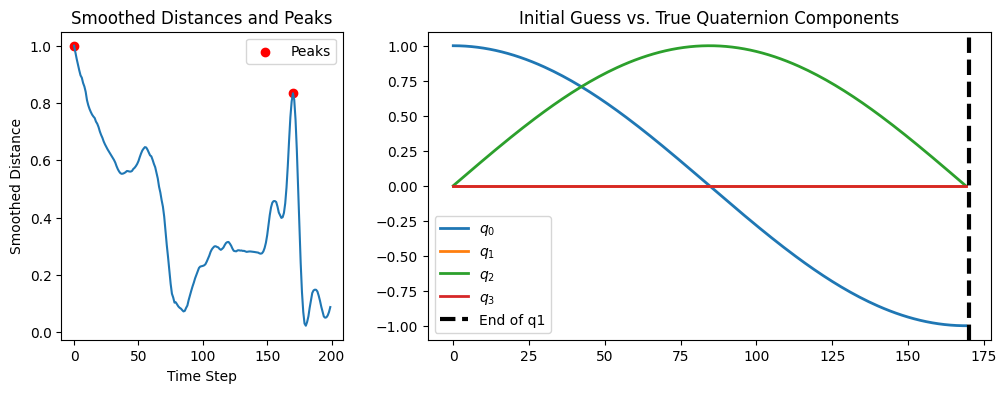

In [26]:
plotter.plot_smooth_dist_intial_guess()

To further validate the VAE, we compare reconstructed frames to the originals and observe a strong visual similarity.

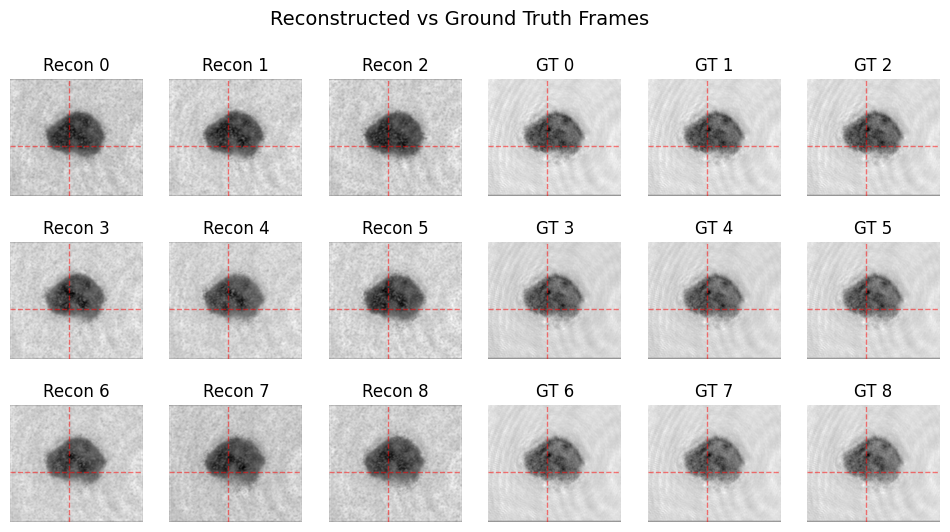

In [27]:
plotter.plot_reconstructed_vs_gt()

In [28]:
tomographic_model.rotation_params = torch.nn.Parameter(torch.tensor(Q_start[:len(tomographic_model.rotation_params)]))
tomographic_model.translation_params = torch.nn.Parameter(torch.tensor(T_start[:len(tomographic_model.rotation_params)]))

# Prepare volume
volume = volume.transpose(1, 2, 0) - 1.33

#tomographic_model.volume = torch.nn.Parameter(torch.tensor(volume).to(DEV))

### 3.3 - Optimize the volume alone first

As outline in the main section, it is now time to proceede with the actual 3D-reconstruction optimization.

The optimization process flows more effectively when an initial 3D volume is optimized first. To achieve this, the volume is optimized for a few iterations before both the volume and rotation parameters are jointly optimized. While it is possible to provide a custom initial volume to begin the optimization, in this case, we start with a fixed volume value of 1.33.

In [29]:
N1 = len(tomographic_model.frames) # Number of frames
#idx = torch.arange(N1) # Index of frames
idx = torch.randperm(N1)
epochs_object_only = 500 # Number of epochs for the object only optimization
rotation_only = 5
batch_size_object_only = 10 # Batch size for the object only optimization

train the model for `epochs_object_only` epochs...

In [30]:
#tomographic_model.volume = nn.Parameter(torch.tensor(volume, dtype=torch.float32).to(DEV)-1.33)

In [31]:
# Move the model to device
tomographic_model.move_all_to_device(DEV)

#tomographic_model.toggle_gradients_quaternion(False)
#tomographic_model.toggle_gradients_translation(False)

# Number of iterations for the training loop
it = epochs_object_only 

trainer = dl.Trainer(max_epochs=it, accelerator="auto", enable_model_summary=True)

start_time = time.time()
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only, shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Train the model
for i in range(it):
    pass
    #print(f"Iteration {i+1} of {it}")

    # First stage: optimize the volume only
    #trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", enable_model_summary=False)

    # Toggle gradients for the volume
    #tomographic_model.toggle_gradients_quaternion(False)
    #tomographic_model.toggle_gradients_translation(False)
    #tomographic_model.toggle_gradients_volume(True)

    #start_time = time.time()
    #trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only, shuffle=True))
    #print("Training time: ", (time.time() - start_time) / 60, " minutes")

    if False:
        # Second stage: optimize the translation and quaternion parameters
        trainer2 = dl.Trainer(max_epochs=rotation_only, accelerator="auto", enable_model_summary=False)

        tomographic_model.toggle_gradients_quaternion(True)
        tomographic_model.toggle_gradients_translation(True)
        tomographic_model.toggle_gradients_volume(False)

        start_time = time.time()
        idx_capping = np.random.randint(0, N1//6)  # Randomly cap the indices to avoid overfitting
        if np.random.rand() < 0.5: idx_capping = 0 # To disable capping

        trainer2.fit(tomographic_model, DataLoader(idx[idx_capping:-idx_capping], batch_size=N1//6, shuffle=False))
        print("Training time: ", (time.time() - start_time) / 60, " minutes") 


c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\core\optimizer.py:317: The lr scheduler dict contains the key(s) ['monitor'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.

  | Name                 | Type                   | Params | Mode 
------------------------------------------------------------------------
0 | vae_model            | VariationalAutoEncoder | 1.1 M  | train
1 | encoder              | Sequential             | 80.1 K | train
2 | fc_mu                | MultiLayerPerceptron   | 281 K  | train
3 | imaging_model        | imaging_model          | 0      | train
4 | train_metrics        | MetricCollection       | 0      | train
5 | val_metrics          | MetricCollection       | 0      | train
6 | test_metrics         | MetricCollection       | 0      | train
7 | convolution_3d_model | Sequential             | 881    | train
8 | optimizer            | Adam                   | 0      | tr

Epoch 19:  53%|█████▎    | 9/17 [00:11<00:10,  0.77it/s, v_num=1382, train_total_loss_step=0.0989, train_proj_loss_step=0.0932, train_rtv_loss_step=0.00108, train_rtr_loss_step=0.00463, train_total_loss_epoch=0.104, train_proj_loss_epoch=0.091, train_rtv_loss_epoch=0.00106, train_rtr_loss_epoch=0.0119]     

NameError: name 'exit' is not defined

In [32]:
tomographic_model.move_all_to_device(DEV)

## 4.0 - Visualize the reconstructed volume and the parameters

Finally, we visualize the reconstructed 3D volume and the rotation parameters. The reconstructed volume is displayed as a 3D volume, while the rotation parameters are represented in a 3D scatter plot.

In [33]:
# Clear the GPU memory
torch.cuda.empty_cache()

In [34]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

By visualizing summation views of the 3D object along the x, y, and z axes, we can assess how well the optimized volume matches the ground truth.

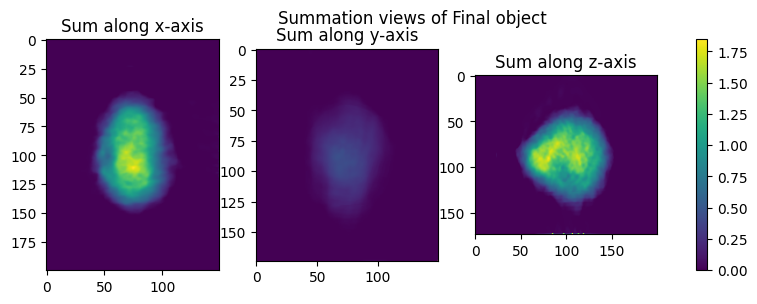

In [35]:
plotter.plot_sum_object(save_name="Final object")

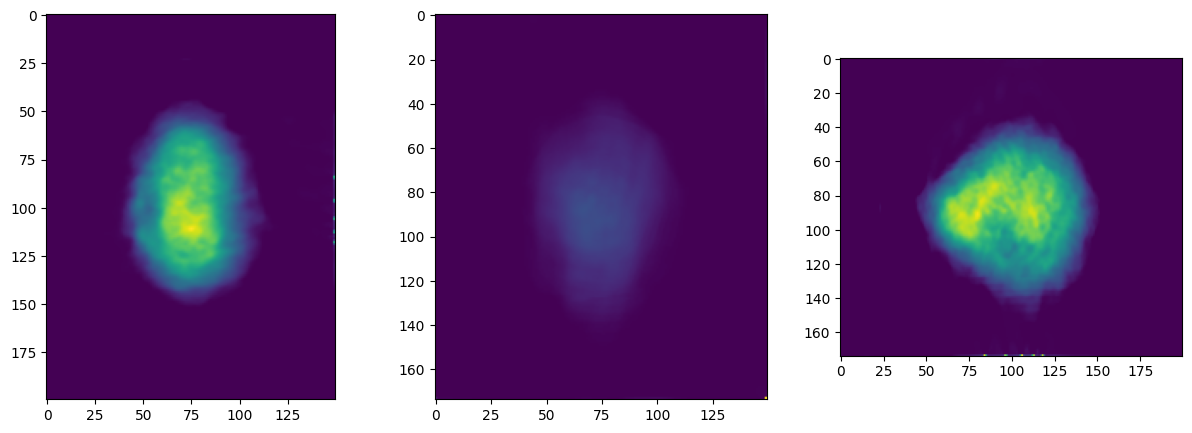

In [36]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(tomographic_model.volume.cpu().detach().numpy().sum(axis=0))

plt.subplot(132)
plt.imshow(tomographic_model.volume.cpu().detach().numpy().sum(axis=1))

plt.subplot(133)
plt.imshow(tomographic_model.volume.cpu().detach().numpy().sum(axis=2))


[[-0.6003914  -0.0273019  -0.7992306  -0.00394324]]
[[ -3.9787316  -1.4188011 -42.212486 ]]


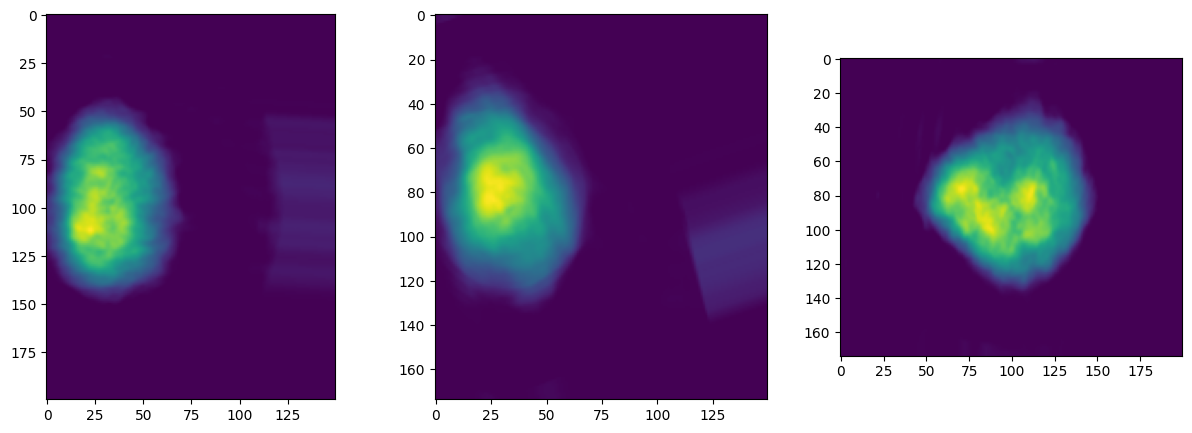

In [37]:
k = 50
print(Q_GT_new[-k:-k+1])
print(T_GT_new[-k:-k+1])
dRI = tomographic_model.apply_rotation_batch(
        tomographic_model.volume, 
        torch.tensor(Q_GT_new[-k:-k+1], device=DEV),
        torch.tensor(T_GT_new[-k:-k+1], device=DEV)
          ).squeeze()

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=0))

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=1))

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=2))

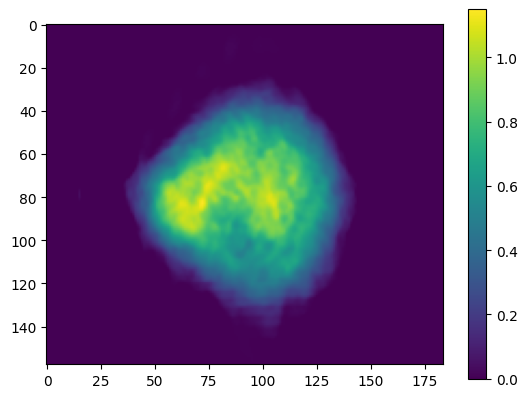

In [38]:
crop = 8
plt.imshow(tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop].detach().cpu().sum(2))
plt.colorbar()

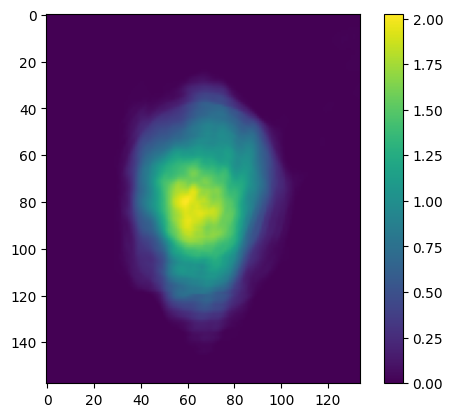

In [39]:
crop = 8
plt.imshow(tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop].detach().cpu().sum(1))
plt.colorbar()

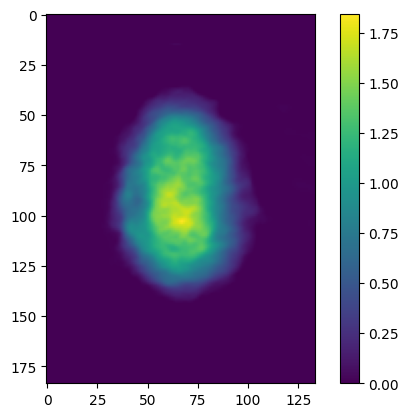

In [40]:
crop = 8
plt.imshow(tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop].detach().cpu().sum(0))
plt.colorbar()

In [41]:
dRI = tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop]

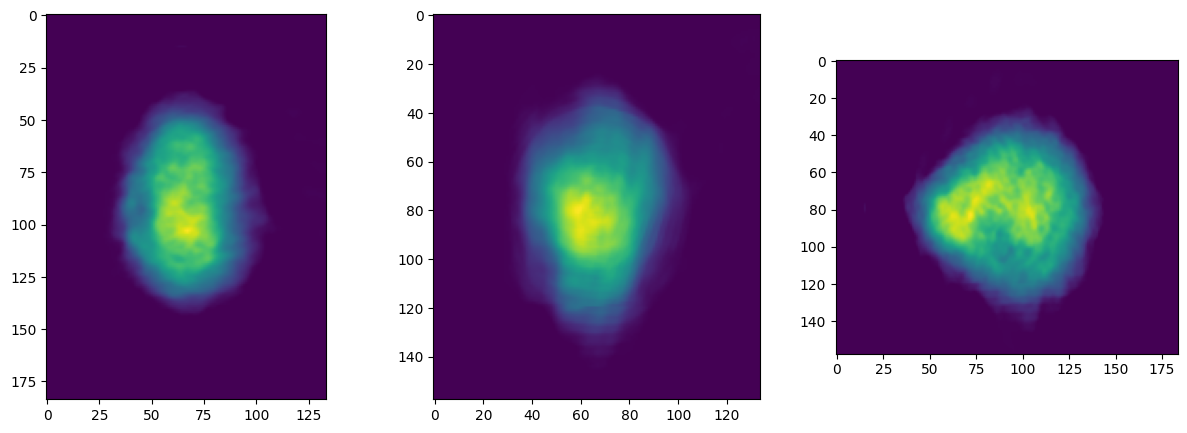

In [42]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=0))

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=1))

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=2))

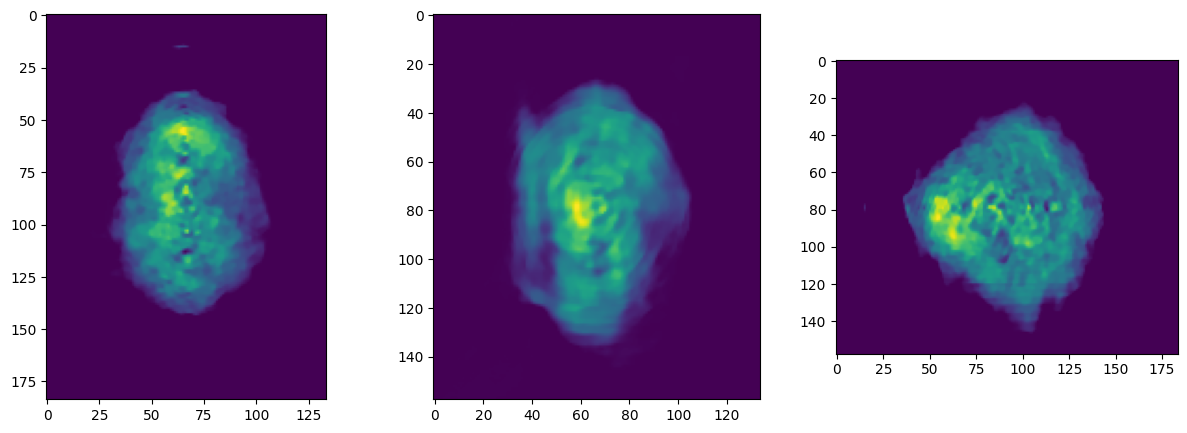

In [43]:
xs, ys, zs = dRI.shape

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy()[xs//2])

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy()[:, ys//2])

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy()[:, :, zs//2])

Instead of summation views, we can visualize the forward projections of the reconstructed object and compare them to the ground truth 2D frames. The similarity indicates a successful reconstruction.

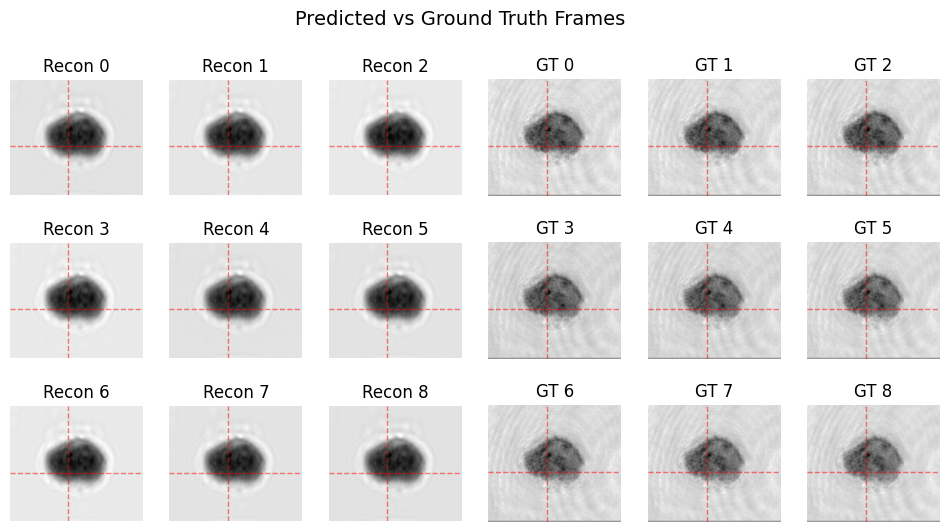

In [44]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

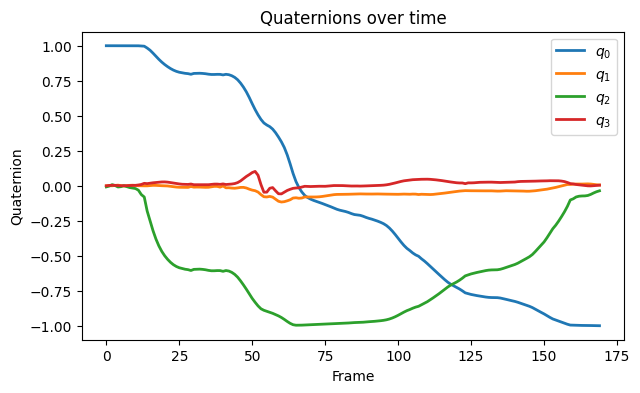

In [45]:
plotter.plot_quaternions()

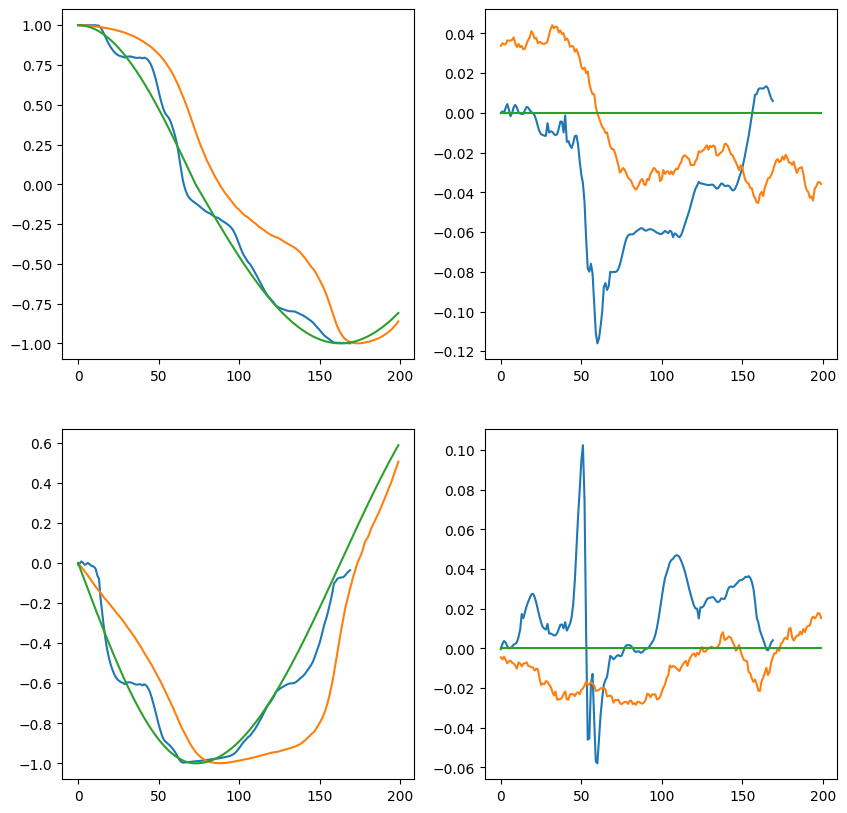

In [46]:
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, 1+i)
    plt.plot(tomographic_model.rotation_params.cpu().detach().numpy()[:, i])
    plt.plot(Q_GT_new[:, i])
    plt.plot(Q_start[:, i])

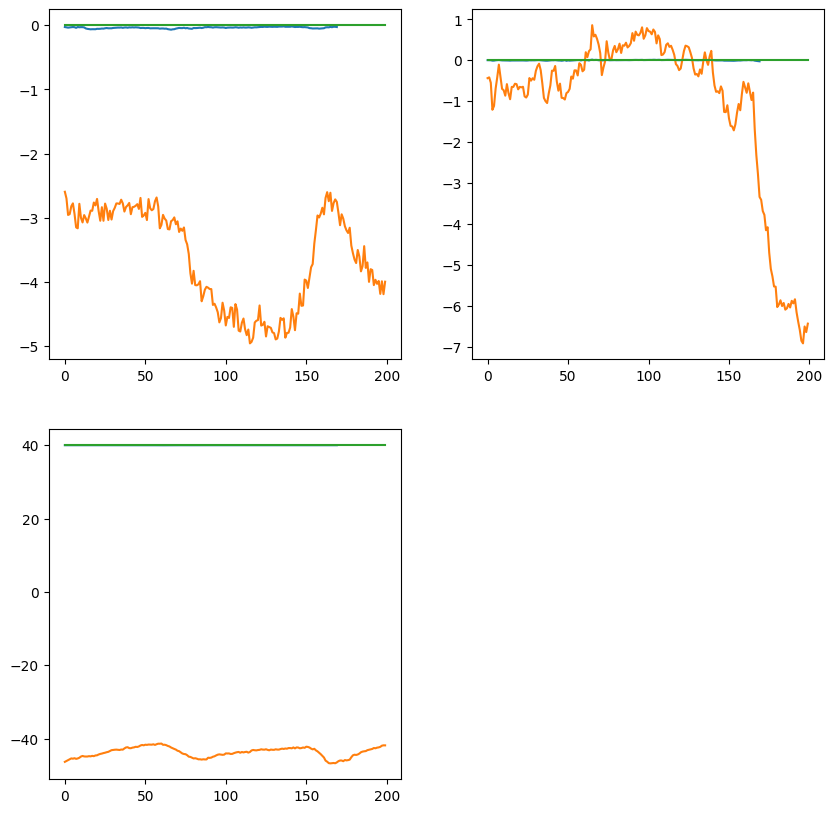

In [47]:
plt.figure(figsize=(10, 10))
for i in range(3):
    plt.subplot(2, 2, 1+i)
    plt.plot(tomographic_model.translation_params.cpu().detach().numpy()[:, i])
    plt.plot(T_GT_new[:, i])
    plt.plot(T_start[:, i])

In [48]:
idx = np.random.randint(0, len(tomographic_model.rotation_params), 10)

In [49]:
forward_projections = tomographic_model.full_forward_final(max_projections=10, idx=idx)

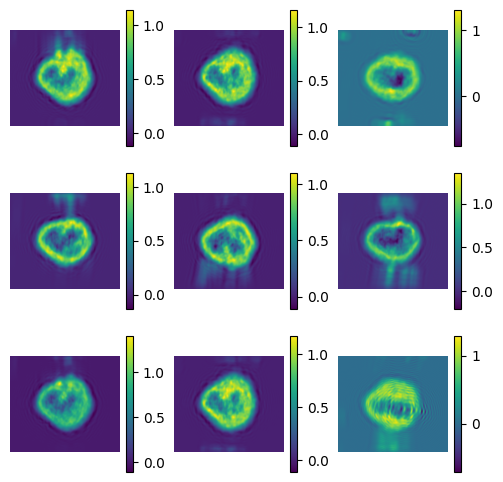

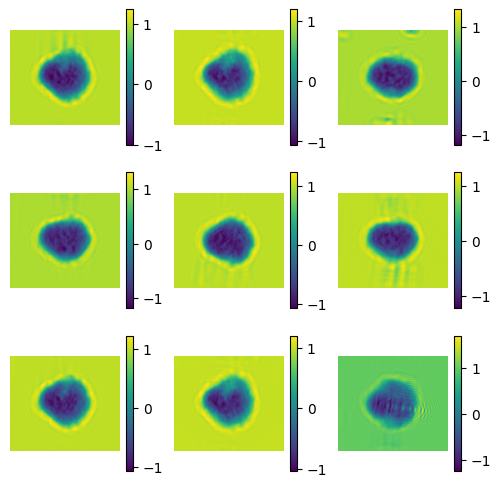

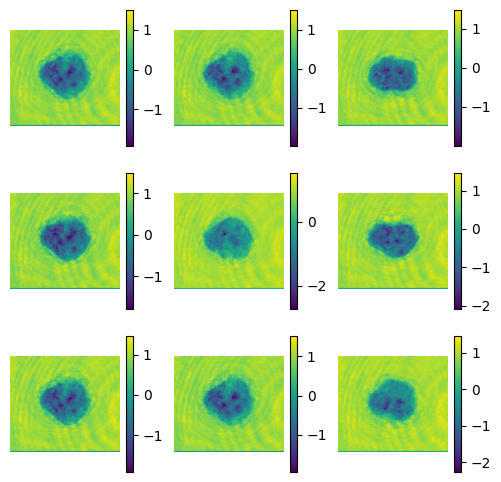

In [50]:
plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 1].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 0].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

# show projections
plt.figure(figsize=(6, 6))
for i, idx_ in enumerate(idx):
    if i >= 9:
        break
    proj_upd = tomographic_model.frames[idx_].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd[0])
    plt.colorbar()
    plt.axis('off')
plt.show()

Text(0.5, 0, 'Frame index')

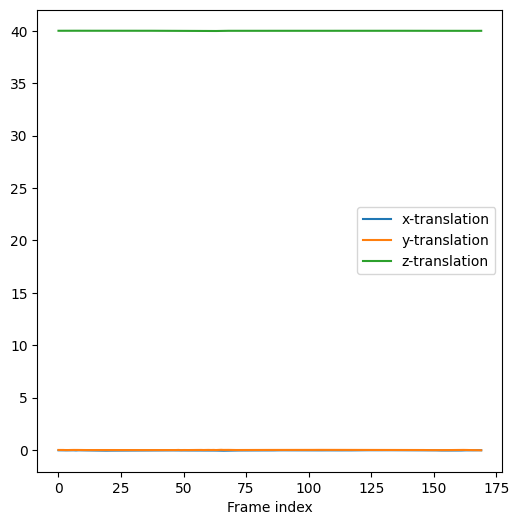

In [51]:
tt =  tomographic_model.get_translations_final()

plt.figure(figsize=(6, 6))
plt.plot(tt[:, 0].detach().cpu().numpy(), label='x-translation')
plt.plot(tt[:, 1].detach().cpu().numpy(), label='y-translation')
plt.plot(tt[:, 2].detach().cpu().numpy(), label='z-translation')
plt.legend()
plt.xlabel('Frame index')

In [85]:
volume = data['n']  # The refractive index volume
volume = volume.transpose(1, 2, 0) - 1.33

In [86]:
Q_GT_new = np.zeros_like(Q_GT)
Q_GT_new[:, 0] = Q_GT[:, 0]
Q_GT_new[:, 1] = -Q_GT[:, 2]
Q_GT_new[:, 2] = -Q_GT[:, 3]
Q_GT_new[:, 3] = -Q_GT[:, 1]

dx = 200e-9
T_GT_new = np.zeros_like(T_GT)
T_GT_new[:, 0] = T_GT[:, 1] / dx
T_GT_new[:, 1] = T_GT[:, 2] / dx
T_GT_new[:, 2] = (T_GT[:, 0] - 150 * dx / 2) / dx

In [87]:
tomographic_model.V0.shape

torch.Size([174, 200, 1])

In [88]:
V0 = brightfield_model(torch.zeros_like(dRI))
if V0.dtype == torch.complex64:
    V0_phase = torch.median(torch.angle(V0))
    V0 = V0 * torch.exp(-1j * V0_phase) # Phase correction
    V0 = V0.squeeze()

full_Eb = []    
for idx_b in range(100,120):
    if idx_b % 10 == 0:
        print(f"Processing frame {idx_b} of {199}")
        
    dRI_b = tomographic_model.apply_rotation_batch(
        torch.tensor(volume, device=DEV), 
        torch.tensor(Q_GT_new[idx_b:idx_b+1], device=DEV),
        torch.tensor(T_GT_new[idx_b:idx_b+1], device=DEV)
          ).squeeze()
    
    Eb = brightfield_model(dRI_b).squeeze()
    
    Eb = Eb * torch.exp(-1j * tomographic_model.V0_phase)  # Phase correction
    Eb = Eb - tomographic_model.V0.squeeze() + 1  # Subtract the initial volume to remove the background

    full_Eb.append(Eb)

Processing frame 100 of 199
Processing frame 110 of 199


In [89]:
"""
    full_Eb = []
        
    for idx_b in range(180, 190):
        if idx_b % 10 == 0:
            print(f"Processing frame {idx_b} of {199}")
            
        proj = tomographic_model.forward(torch.tensor([idx_b], device=DEV))

        field = proj[:,0] + 1j * proj[:,1]




        full_Eb.append(field)

    Eb = field.squeeze()

"""

'\n    full_Eb = []\n\n    for idx_b in range(180, 190):\n        if idx_b % 10 == 0:\n            print(f"Processing frame {idx_b} of {199}")\n\n        proj = tomographic_model.forward(torch.tensor([idx_b], device=DEV))\n\n        field = proj[:,0] + 1j * proj[:,1]\n\n\n\n\n        full_Eb.append(field)\n\n    Eb = field.squeeze()\n\n'

In [90]:
full_Eb = torch.stack(full_Eb, dim=0)

In [91]:
Eb.shape

torch.Size([174, 200])

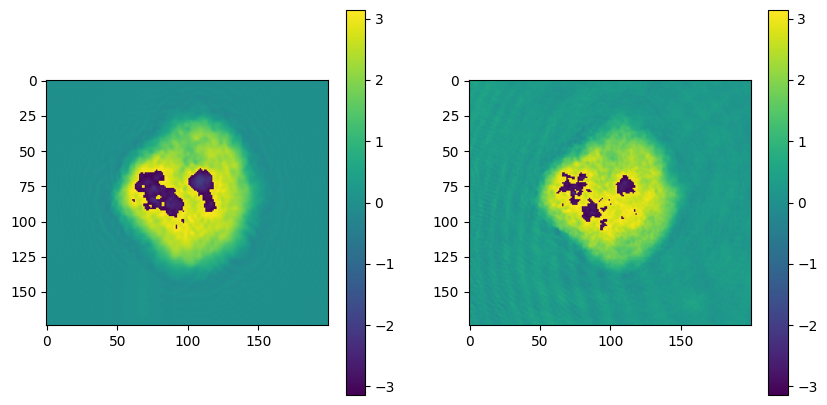

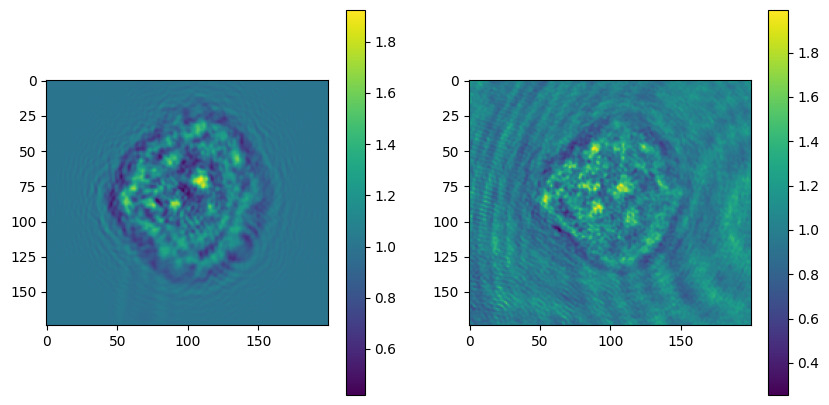

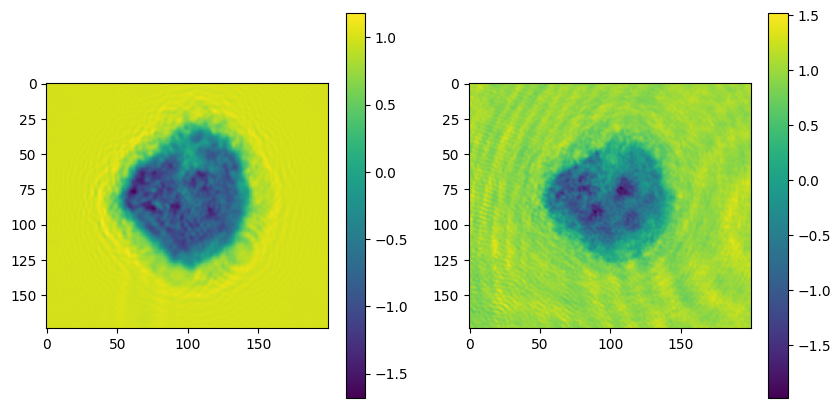

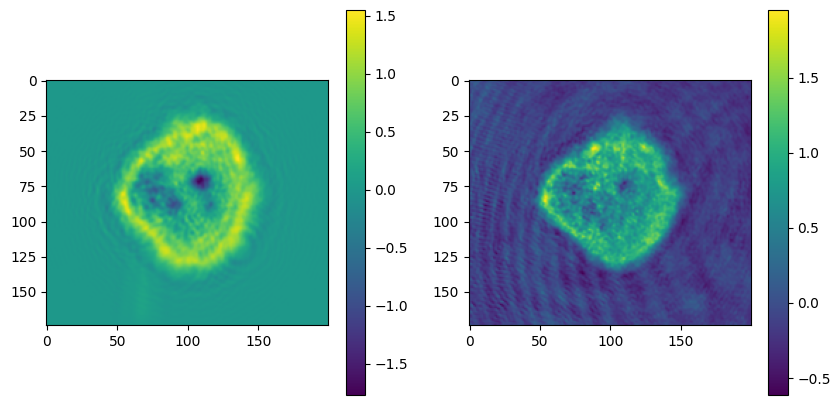

In [92]:
Ee = data['E'][index_min:index_max]
Ee = torch.tensor(Ee, dtype=torch.complex64).to(DEV)
Eem = Ee * torch.exp(-1j * torch.angle(Ee[:, :20, :20]).mean(axis=(1,2), keepdims=True))

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.angle(Eb.cpu().detach().numpy()))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.angle(Ee.cpu().detach().numpy()[idx_b]))
plt.colorbar()

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.abs(Eb.cpu().detach().numpy()))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.abs(Eem.cpu().detach().numpy()[idx_b]))
plt.colorbar()

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.real(Eb.cpu().detach().numpy()))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.real(Eem.cpu().detach().numpy()[idx_b]))
plt.colorbar()

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.imag(Eb.cpu().detach().numpy()))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.imag(Eem.cpu().detach().numpy()[idx_b]))
plt.colorbar()

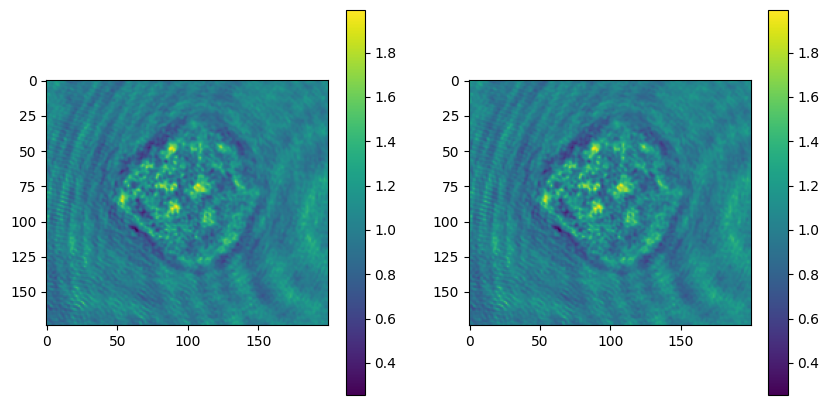

In [93]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.abs(Eem.cpu().detach().numpy()[idx_b]))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.abs(Ee.cpu().detach().numpy()[idx_b]))
plt.colorbar()